In [1]:
"""
S01 MPO training — integrate notebooks 01–07 mission context.

Scenario:
  - Same mission profile as notebook 07 baseline overflight (50-target meridian grid,
    seeded clouds over the corridor, dual camera, attitude safety on, image quality)
  - Controller features selected via ControllerFeatureConfig (see cell below)
  - 10× baseline overflight warmup (sliced target windows per ep, wrap mod n_chunks) → train → eval
  - Preflight: inline feature checks + full ML training pytest suite

Verification: s01_utils/training_workflow.py
Artifacts: autonomous_control/models/nb-s01-08-<timestamp>/
Export: eval_best.mp4 in run directory
"""

'\nS01 MPO training — integrate notebooks 01–07 mission context.\n\nScenario:\n  - Same mission profile as notebook 07 baseline overflight (50-target meridian grid,\n    seeded clouds over the corridor, dual camera, attitude safety on, image quality)\n  - Controller features selected via ControllerFeatureConfig (see cell below)\n  - 10× baseline overflight warmup (sliced target windows per ep, wrap mod n_chunks) → train → eval\n  - Preflight: inline feature checks + full ML training pytest suite\n\nVerification: s01_utils/training_workflow.py\nArtifacts: autonomous_control/models/nb-s01-08-<timestamp>/\nExport: eval_best.mp4 in run directory\n'

In [2]:
def setup_notebook_paths():
    """
    Configure Python paths and working directory for running the S01 training notebook.

    - Walks up directories from the current working directory until it finds the 'simulation' folder,
      which marks the backend root.
    - Changes the working directory to the backend root to ensure relative paths are correct.
    - Adds both the backend root and the S01 notebook utilities directory to sys.path for imports.

    This setup is required for importing backend modules and utility code in other cells.
    """
    import os
    import sys
    from pathlib import Path

    notebook_dir = Path.cwd()
    backend_root = notebook_dir
    for _ in range(6):
        if (backend_root / "simulation").is_dir():
            break
        backend_root = backend_root.parent
    os.chdir(backend_root)
    sys.path.insert(0, str(backend_root))
    _s01_dir = backend_root / "notebooks" / "s01"
    sys.path.insert(0, str(_s01_dir))
    print(f"backend_root={backend_root}")

setup_notebook_paths()

backend_root=c:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend


In [3]:
import importlib

import s01_utils.training_workflow as tw

importlib.reload(tw)

# Fast gate: inline checks + unit pytest (~3s). Re-runs are skipped via session/disk cache.
# For full serial episode-runner tests (~80s): tw.run_s01_training_preflight_gate(integration_pytest=True, force=True)
tw.run_s01_training_preflight_gate()

c:\Users\cedri\miniconda3\envs\auto-sat\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Using device: cpu
Using device: cpu


True

In [4]:
from dataclasses import replace

# Single source of truth: s01_utils/training_workflow.py (timestep keys + mission scalars).
# Customize with replace(), e.g. replace(tw.S01_TRAINING_FEATURE_CONFIG, include_capture_budget=False)
FEATURE_CONFIG = tw.S01_TRAINING_FEATURE_CONFIG

WORKFLOW_CONFIG = tw.TrainingWorkflowConfig(
    seed=7,
    feature_config=FEATURE_CONFIG,
    ###########
    warmup_targets_per_episode=10,
    warmup_episodes=5,
    use_warmup_bundle_cache=True,
    ##########
    train_episodes=10,
    ##########
    eval_episodes=2,
)

# Mission profile for layout tables (same as training).
_mission_resolved = tw.build_s01_training_mission_setup(seed=WORKFLOW_CONFIG.seed).resolve(
    require_camera=True
)
_secondary_bins = int(_mission_resolved.secondary_camera_observation_line_n_bins)
_n_targets = len(_mission_resolved.target_areas or ())
tw.display_feature_tables(
    FEATURE_CONFIG,
    secondary_camera_bins=_secondary_bins,
    n_mission_targets=_n_targets,
)

### Controller feature selection (`ControllerFeatureConfig`)

Edit `S01_TRAINING_FEATURE_CONFIG` in `s01_utils/training_workflow.py` (timestep key tuples **and** `include_capture_budget` / `include_target_bearing_errors`). Notebook 08 should assign `FEATURE_CONFIG = tw.S01_TRAINING_FEATURE_CONFIG` rather than duplicating keys.

,group,timestep_key,state_dims,unit,encoder_path,source_module
0,attitude,body_z_angle_rad,1,rad,scalar → MLP branch,autonomous_control/feature_selection.py
1,attitude,omega_sat_rad_s,1,rad/s,scalar → MLP branch,autonomous_control/feature_selection.py
2,orbit,theta_orbit_rad,1,rad,scalar → MLP branch,autonomous_control/feature_selection.py
3,orbit,primary_camera_image_quality,1,1,scalar → MLP branch,autonomous_control/feature_selection.py
4,vision,camera_observation_line_codes,100,obs code / bin,int8 codes → embed → 1D-CNN,autonomous_control/feature_selection.py
5,vision,secondary_camera_observation_line_codes,200,obs code / bin,int8 codes → embed → 1D-CNN,autonomous_control/feature_selection.py
6,mission,capture_budget_remaining,1,count,scalar → MLP branch,autonomous_control/controller_observation.py
7,mission,target_bearing_error_rad_0,1,rad,scalar → MLP branch,autonomous_control/controller_observation.py
8,mission,target_bearing_error_rad_1,1,rad,scalar → MLP branch,autonomous_control/controller_observation.py
9,mission,target_bearing_error_rad_2,1,rad,scalar → MLP branch,autonomous_control/controller_observation.py


### Controller encoder routing (scalar **55**, vision streams **2**)

,stage,inputs,input_shape,module
0,scalar branch,"body_z_angle_rad, omega_sat_rad_s, theta_orbit...","(55,) float32",MLP → 90-D
1,vision branch (primary (nadir)),camera_observation_line_codes,"(100,) int8","ObservationLineCNNEncoder (2×Conv1d, k=5) → 32-D"
2,vision branch (secondary (forward)),secondary_camera_observation_line_codes,"(200,) int8","ObservationLineCNNEncoder (2×Conv1d, k=5) → 32-D"
3,vision fusion,concat CNN embeddings,"(64,)",MLP → 90-D
4,policy / Q trunk,"concat(scalar, vision)","(180,)",Actor head / Critic head


### Observation code legend (vision line bins)

,code,label
0,-99,not_computed
1,0,space
2,1,earth
3,2,cloud
4,3,target


In [5]:
setup = tw.build_training_workflow_setup(WORKFLOW_CONFIG)
tw.print_training_setup_summary(setup)
tw.display_feature_snapshot_tables(setup)

Using device: cpu
S01 MPO training setup (notebook 07 baseline overflight profile)
  run_dir:           C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06
  seed:              7
  altitude:          528.8 km
  targets:           50
  clouds:            25 (seeded over target corridor)
  orbit window:      -32.7° .. 37.1°
  episode steps:     1936
  attitude safety:   on (training_episode_simulation_config)
  scalar dim:        55
  vision streams:    [('camera_observation_line_codes', 100), ('secondary_camera_observation_line_codes', 200)]
  encoder trunk:     180-D
  secondary bins:    200
  feature keys:      ['body_z_angle_rad', 'omega_sat_rad_s', 'theta_orbit_rad', 'primary_camera_image_quality', 'camera_observation_line_codes', 'secondary_camera_observation_line_codes']
  warmup episodes:   5
  train episodes:    10
  eval episodes:     2
  MPO batch_size:    256
  MPO gamma:         0.99
  MPO LRs q/pi/eta

c:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\simulation\stepper.py:170: UserWarning: controller_update_interval (1 s) is not an integer multiple of simulation_timestep (0.4 s); using nearest multiple: 0.8 s (2 sim steps).
  self._controller_interval_steps, self._effective_controller_interval_s = resolve_controller_interval_steps(


### Scalar features at episode start (MLP branch)

,scalar_index,group,timestep_key,value,unit
0,0,attitude,body_z_angle_rad,4.324486,rad
1,1,attitude,omega_sat_rad_s,0.000000,rad/s
2,2,orbit,theta_orbit_rad,1.182893,rad
3,3,orbit,primary_camera_image_quality,0.283001,1
4,4,mission,capture_budget_remaining,10.000000,count
5,5,mission,target_bearing_error_rad_0,-1.107960,rad
6,6,mission,target_bearing_error_rad_1,-1.116560,rad
7,7,mission,target_bearing_error_rad_2,-1.124297,rad
8,8,mission,target_bearing_error_rad_3,-1.131252,rad
9,9,mission,target_bearing_error_rad_4,-1.137496,rad


### Vision line features at episode start (CNN branches)

,camera,timestep_key,n_bins,preview,dominant_code,target_bins
0,primary (nadir),camera_observation_line_codes,100,"[1, 1, 1, 1, 1, 1, 1, 1, …]",1 (earth),0
1,secondary (forward),secondary_camera_observation_line_codes,200,"[1, 1, 1, 1, 1, 1, 1, 1, …]",1 (earth),0


Structured `ControllerObservation`: scalars **55**, vision **camera_observation_line_codes 100 bins, secondary_camera_observation_line_codes 200 bins** → encoder trunk **180**-D.

In [6]:
result = tw.run_training_workflow(setup, show_progress=True)

Warmup:   0%|          | 0/5 [00:00<?, ?ep/s]

╭───────────────────────────────────────────── Simulation info ──────────────────────────────────────────────╮
│  Parameter                          Value                                                                  │
│  episode duration                   773.95 s                                                               │
│  simulation timestep                0.399975 s                                                             │
│  integration steps                  1935 (+1 state samples)                                                │
│  orbit altitude                     528.76 km                                                              │
│  orbit period                       5703.8 s                                                               │
│  episode theta start (rel. center)  -32.693 deg                                                            │
│  episode theta end (rel. center)    37.091 deg                                                             │
│  sat motion span scale              0.700                                                                  │
│  target areas                       50                                                                     │
│  cloud patches                      25                                                                     │
│  render mode                        headless                                                               │
│  pilot                              Sequential baseline                                                    │
│  rollout                            warmup                                                                 │
│  controller update (configured)     1 s                                                                    │
│  controller update (effective)      0.8 s (2 steps)                                                        │
│  reaction-wheel torque max          0.1000 N*m                                                             │
│  attitude safe-mode limit           off-nadir > 45 deg → brake, nadir recovery, then lockout               │
│  attitude safe-mode lockout         60 s with no agent torque after nadir recovery                         │
│  attitude RW rate limit             |omega_sat| > 3.00 deg/s → block opposing torque                       │
│  reward (capture)                   applied on shutter: coverage × quality × (1 − clouds); latent every    │
│                                     step                                                                   │
│  Camera 1 (primary)                                                                                        │
│    role                             shapes reward (observation line + cloud fraction)                      │
│    tilt off nadir                   0.00 deg                                                               │
│    FOV (cross x along)              1.61 deg x 1.20 deg                                                    │
│    resolution                       9344 x 7000 px                                                         │
│    pixel pitch                      3.20 um                                                                │
│    focal length                     1067.0 mm                                                              │
│    GSD @ 528.8 km                   1.586 m                                                                │
│    observation line bins            100                                                                    │
│    sim vertical FOV                 1.203 deg                                                              │
│    exposure time                    100 us (image smear)                                                   │
│  Camera 2 (secondary)                                                                                      │
│    role                             cloud/context only (no exposure in reward)                             │
│   

╭──────────────────────────────────────────────── Live stats ────────────────────────────────────────────────╮
│  Parameter              Value                                                                              │
│  episode                warmup ep 1 / 5                                                                    │
│  step                   1600 / 1935 (82.7%)                                                                │
│  sim time               640.0 s                                                                            │
│  reward                 145.37                                                                             │
│  shutter budget         0 remaining                                                                        │
│  safe mode activations  0                                                                                  │
│  body z angle           -1.2537 rad                                                                        │
│  omega sat              0.0011 rad/s                                                                       │
│  image smear            0.442 px                                                                           │
│  image quality          0.2999                                                                             │
│  buffer                 1599                                                                               │
│  agent steps            1599                                                                               │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Live stats ────────────────────────────────────────────────╮
│  Parameter              Value                                                                              │
│  episode                warmup ep 1 / 5                                                                    │
│  step                   1935 / 1935 (100.0%)                                                               │
│  sim time               774.0 s                                                                            │
│  reward                 145.37                                                                             │
│  shutter budget         0 remaining                                                                        │
│  safe mode activations  0                                                                                  │
│  body z angle           -1.1061 rad                                                                        │
│  omega sat              0.0011 rad/s                                                                       │
│  image smear            0.442 px                                                                           │
│  image quality          0.2998                                                                             │
│  buffer                 1934                                                                               │
│  agent steps            1934                                                                               │
│  status                 episode done                                                                       │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

warmup ep 1: 100%|██████████| 1935/1935 [00:48<00:00, 40.22step/s, budget=0, return=145.4, safe=0]

...

╭──────────────────────────────────────────────── Live stats ────────────────────────────────────────────────╮
│  Parameter              Value                                                                              │
│  episode                eval ep 2 / 2                                                                      │
│  step                   1935 / 1935 (100.0%)                                                               │
│  sim time               774.0 s                                                                            │
│  reward                 0.00                                                                               │
│  shutter budget         10 remaining                                                                       │
│  safe mode activations  6                                                                                  │
│  body z angle           -0.7262 rad                                                                        │
│  omega sat              0.0498 rad/s                                                                       │
│  image smear            1.413 px                                                                           │
│  image quality          0.1106                                                                             │
│  buffer                 29025                                                                              │
│  agent steps            29025                                                                              │
│  exploration            deterministic (policy mean)                                                        │
│  status                 episode done                                                                       │
╰────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

eval ep 2: 100%|██████████| 1935/1935 [01:35<00:00, 20.27step/s, budget=10, return=0.0, safe=6]

Eval: 100%|██████████| 2/2 [03:11<00:00, 95.98s/ep, reward=0.0]


[run_serial] end mode=eval steps=1935 total_reward=0.000000 avg_reward=0.000000



Writing video: 100%|██████████| 861/861 [02:12<00:00,  6.49frame/s]


In [7]:
tw.print_training_kpis(result)

Training KPIs
  checkpoint:        C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\agent.pt
  run_dir:           C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06
  train:
    episodes:        10
    mean return:     0.00 ± 0.00
    best return:     0.00 (ep 1)
  eval:
    episodes:        2
    mean return:     0.00 ± 0.00
    best return:     0.00 (ep 1)


### Training artifacts

**returns_plot** — `C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\plots\returns_by_episode.png`

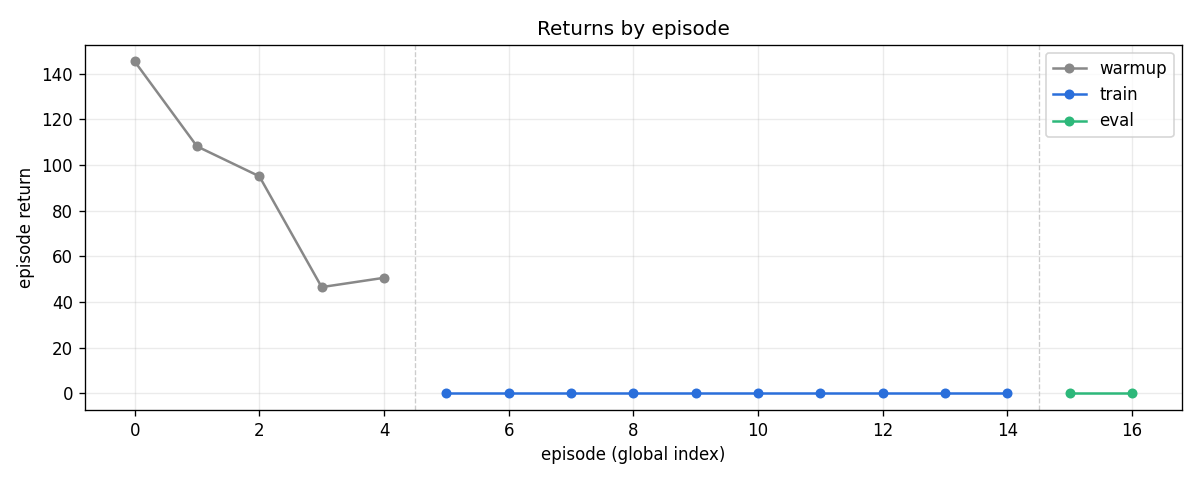

**learning_curves_plot** — `C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\plots\learning_curves.png`

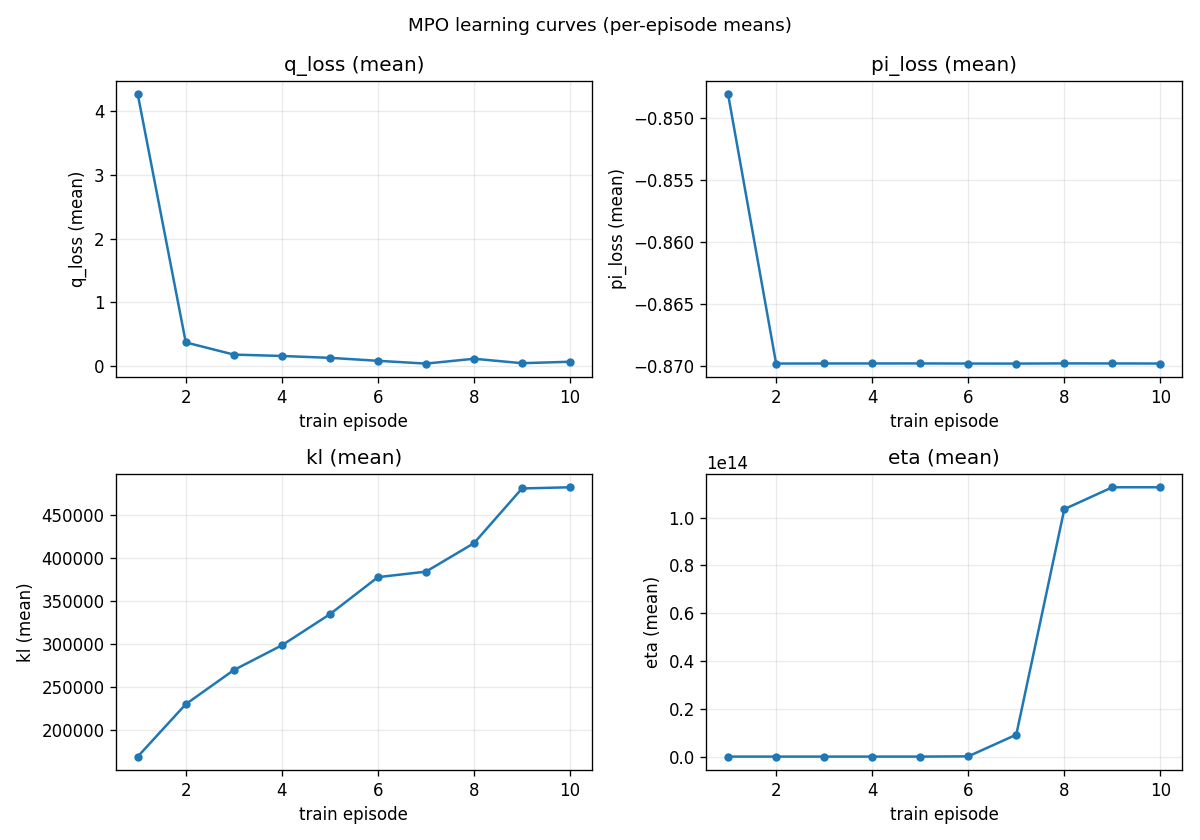

**train_last_reward_plot** — `C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\episodes\train_last_reward.png`

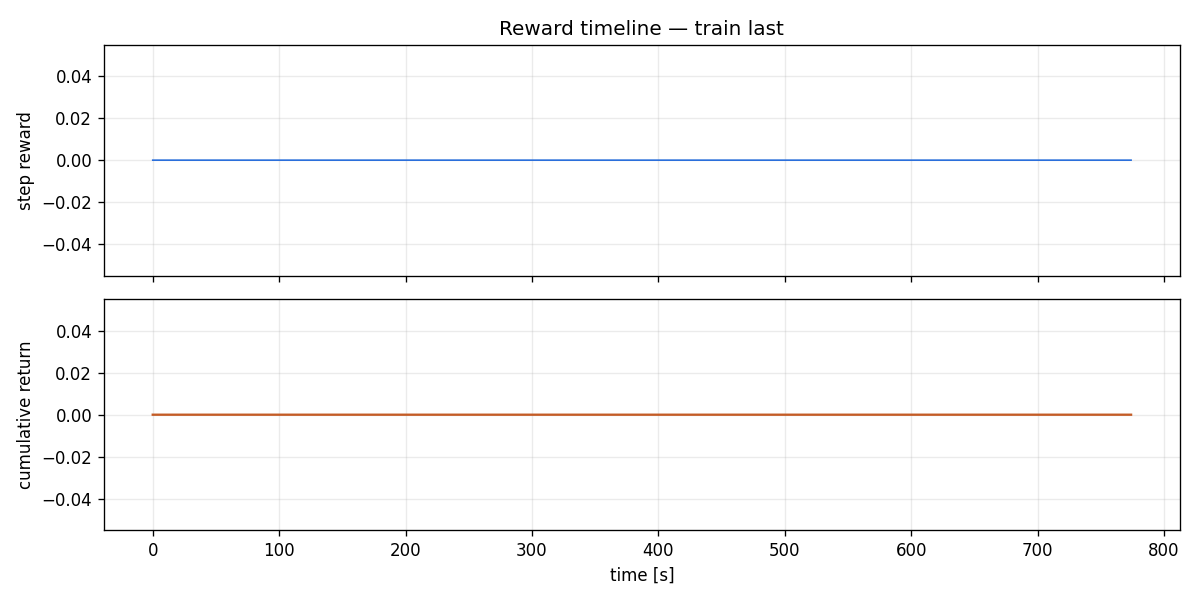

**eval_best_reward_plot** — `C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\episodes\eval_best_reward.png`

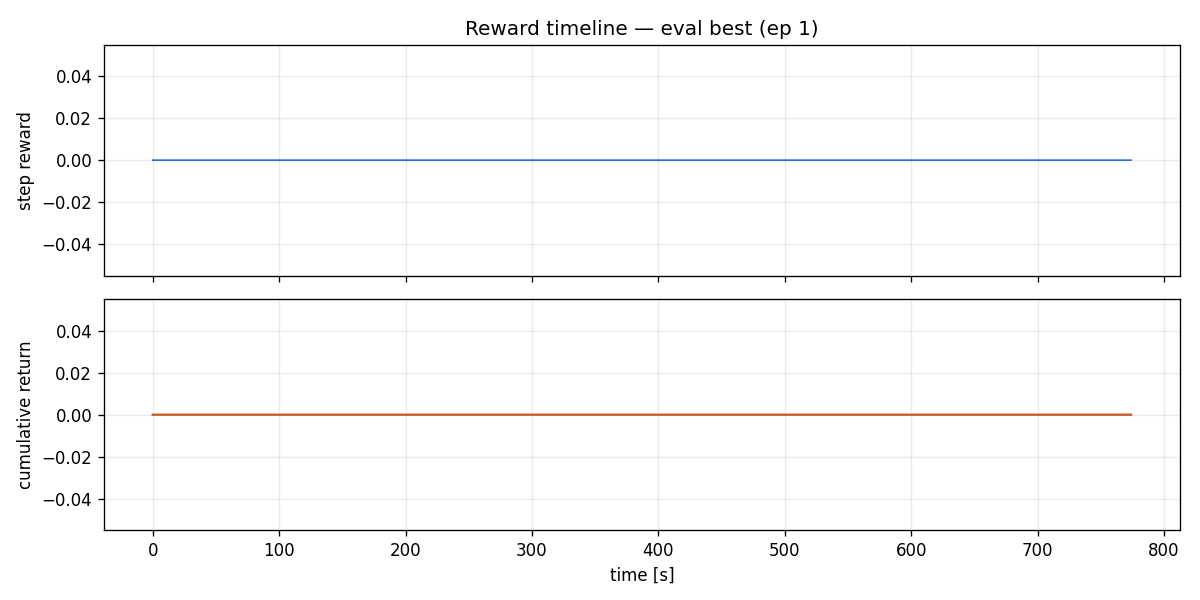

**eval_best_video** — `C:\Users\cedri\code\autonomous-satellite-control-eth-sem-proj\backend\autonomous_control\models\nb-s01-08-2026-06-27_13-50-06\videos\eval_best.mp4`

[mpo_video:play] eval_best.mp4 (2782349 bytes, codec=h264)


In [8]:
from utils.notebook.video import init_video_cell, play_saved_video

init_video_cell()

from utils.notebook.video import init_video_cell, play_saved_video

init_video_cell()
tw.display_training_artifacts(result)
video_path = result.artifact_paths["eval_best_video"]
if video_path.exists():
    play_saved_video(video_path)